In [2]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")

import math
import numpy as np
import CoolProp.CoolProp as CP
from Cp0massWrapper import Cp0mass_Wrapper
from pyDecomposition import Dehydrator
from pyPinch import PyPinch
from pyBrayton import Brayton
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

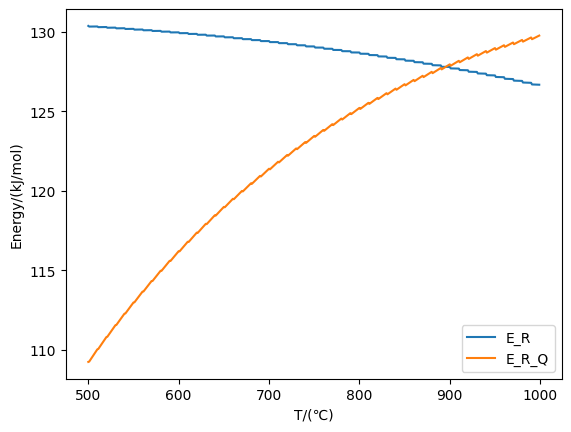

In [17]:
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
M_caco3 = 100e-3  # kg/mol
M_H2O = 18e-3  # kg/mol
M_CO2 = 44e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["flue_gas_composition2"] = flue_gas_composistion2
pw = Cp0mass_Wrapper(parameters["flue_gas_composition"],parameters["flue_gas_composition2"])
P = 101325 
X = range(500, 1000) 
Y1 = [] 
Y2 = []
for T in X: 
    s0 = CP.PropsSI('S', 'T', 20+273.15, 'P', P, "REFPROP::co2")
    h0 = CP.PropsSI('H', 'T', 20+273.15, 'P', P, "REFPROP::co2")
    s1 =  CP.PropsSI('S', 'T', T+273.15, 'P', P, "REFPROP::co2")
    h1 = CP.PropsSI('H', 'T', T+273.15, 'P', P, "REFPROP::co2")
    Q_co2 = (h1-h0)* M_CO2   #energy gcpw=(T-20-293.15*math.log((T+273.15)/293.15))/(T-20)  exergy = b*gcpw
    Q_cao = pw.cp0mass_mean("cao", T, 20)*M_cao*(T-20)
    Q_caco3 = pw.cp0mass_mean("caco3", T, 20)*M_caco3*(T-20)  #j/mol
    Q_R = 178e3+Q_co2+Q_cao-Q_caco3
    gcpw=(T-20-293.15*math.log((T+273.15)/293.15))/(T-20)
    E_co2 = ((h1-293.15*s1)-(h0-293.15*s0))* M_CO2 #j/mol exergy
    E_cao = Q_cao*gcpw
    E_caco3 =Q_caco3*gcpw
    E_R = (130.9e3+E_co2+E_cao-E_caco3)/1000
    gcpw2=1-(293.15)/(T+273.15)
    E_R_Q = Q_R*gcpw2/1000
    Y1.append(E_R)
    Y2.append(E_R_Q)
plt.plot(X, Y1, label='E_R') 
plt.plot(X, Y2, label='E_R_Q') 
plt.xlabel('T/(℃)') 
plt.ylabel('Energy/(kJ/mol)') 
plt.legend() 
plt.show()



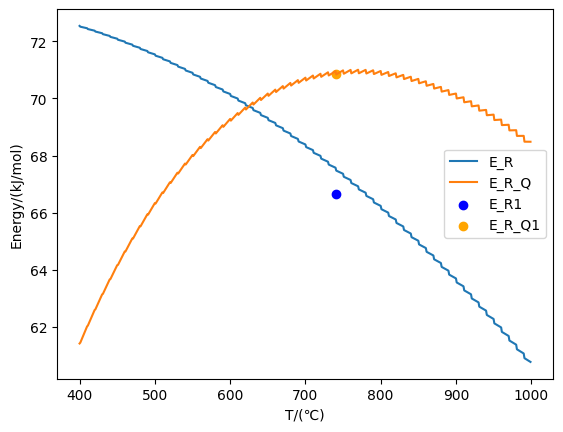

In [7]:
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
M_caco3 = 100e-3  # kg/mol
M_H2O = 18e-3  # kg/mol
M_CO2 = 44e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["flue_gas_composition2"] = flue_gas_composistion2
pw = Cp0mass_Wrapper(parameters["flue_gas_composition"],parameters["flue_gas_composition2"])
P = 3001325 
X = range(400, 1000) 
Y1 = [] 
Y2 = []
for T in X: 
    T_vaporization = CP.PropsSI('T', 'P', P, 'Q', 1, "REFPROP::water")
    s0 = CP.PropsSI('S', 'T', 20+273.15, 'P', 101325, "REFPROP::water")
    h0 = CP.PropsSI('H', 'T', 20+273.15, 'P', 101325, "REFPROP::water")
    s1 =  CP.PropsSI('S', 'T', T+273.15, 'P', P, "REFPROP::water")
    h1 = CP.PropsSI('H', 'T', T+273.15, 'P', P, "REFPROP::water")
    h_vaporization = (CP.PropsSI('H', 'T', T_vaporization+1, 'P', P, "REFPROP::water") - 
                      CP.PropsSI('H', 'T', T_vaporization-1, 'P', P, "REFPROP::water") )
    Q_h2o = (h1-h0-h_vaporization)* M_H2O    #energy gcpw=(T-20-293.15*math.log((T+273.15)/293.15))/(T-20)  exergy = b*gcpw
    Q_cao = pw.cp0mass_mean("cao", T, 20)*M_cao*(T-20)
    Q_caoh2 = pw.cp0mass_mean("caoh2", T, 20)*M_caoh2*(T-20)  #j/mol
    Q_R = 104e3+Q_h2o+Q_cao-Q_caoh2
    gcpw=(T-20-293.15*math.log((T+273.15)/293.15))/(T-20)
    E_h2o = ((h1-293.15*s1)-(h0-293.15*s0))* M_H2O #j/mol exergy
    E_cao = Q_cao*gcpw
    E_caoh2 =Q_caoh2*gcpw
    E_R = (57.8e3+E_h2o+E_cao-E_caoh2)/1000
    gcpw2=1-(293.15)/(T+273.15)
    E_R_Q = Q_R*gcpw2/1000
    Y1.append(E_R)
    Y2.append(E_R_Q)
plt.plot(X, Y1, label='E_R') 
plt.plot(X, Y2, label='E_R_Q') 
plt.scatter([740], [66.64], color='blue', label='E_R1') 
plt.scatter([740], [70.87], color='orange', label='E_R_Q1') 
plt.xlabel('T/(℃)') 
plt.ylabel('Energy/(kJ/mol)') 
plt.legend() 
plt.show()



In [9]:
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
M_caco3 = 100e-3  # kg/mol
M_H2O = 18e-3  # kg/mol
M_CO2 = 44e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["flue_gas_composition2"] = flue_gas_composistion2
pw = Cp0mass_Wrapper(parameters["flue_gas_composition"],parameters["flue_gas_composition2"])
P = 3001325 
T=740
T_vaporization = CP.PropsSI('T', 'P', P, 'Q', 1, "REFPROP::water")
s0 = CP.PropsSI('S', 'T', 20+273.15, 'P', 101325, "REFPROP::water")
h0 = CP.PropsSI('H', 'T', 20+273.15, 'P',101325, "REFPROP::water")
s1 =  CP.PropsSI('S', 'T', T+273.15, 'P', P, "REFPROP::water")
h1 = CP.PropsSI('H', 'T', T+273.15, 'P', P, "REFPROP::water")
h_vaporization = (CP.PropsSI('H', 'T', T_vaporization+1, 'P', P, "REFPROP::water") - 
                  CP.PropsSI('H', 'T', T_vaporization-1, 'P', P, "REFPROP::water") )
Q_h2o = (h1-h0-h_vaporization)* M_H2O   #energy gcpw=(T-20-293.15*math.log((T+273.15)/293.15))/(T-20)  exergy = b*gcpw
Q_cao = pw.cp0mass_mean("cao", T, 20)*M_cao*(T-20)
Q_caoh2 = pw.cp0mass_mean("caoh2", T, 20)*M_caoh2*(T-20)  #j/mol
Q_R = 104+38.08+37.03-79.38
gcpw=(T-20-293.15*math.log((T+273.15)/293.15))/(T-20)
E_h2o = ((h1-293.15*s1)-(h0-293.15*s0))* M_H2O #j/mol exergy
E_cao = Q_cao*gcpw
E_caoh2 =Q_caoh2*gcpw
E_R = (57.8e3+30660+18176-39999)/1000
gcpw2=1-(293.15)/(T+273.15)
E_R_Q = Q_R*gcpw2
print(T_vaporization,Q_h2o,E_h2o,E_R,E_R_Q)



507.02759893056304 38131.54608391226 30713.983705277198 66.637 70.87361200217144
